In [ ]:
print("HELLO WORLD")

HELLO WORLD


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import jax
import jax.numpy as jnp

import wavefunctions, trajectory, optimization

### Plot hyperparameter sampling trials

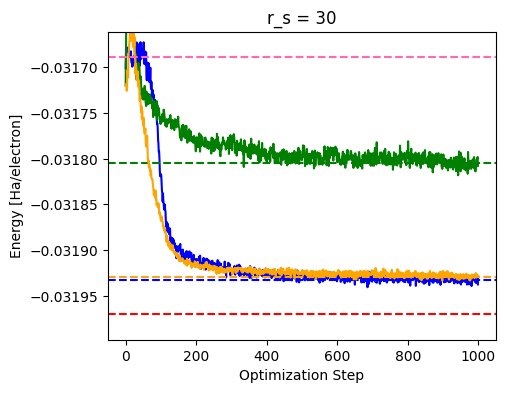

In [4]:
path = "joint/{}/rs{}_best/{}"

r_ws = "30"
dim = 2

optSteps = 1000

modes = [ "dynamic" , "static" , "joint-early" ]
colors = [ "blue" ,  "green" , "orange" , "purple" ]

if dim == 2:
    hard_vals = {
        "10" : ( -0.084474 , np.nan , np.nan ),
        "20" : ( -0.045929 , -0.045975 , -0.04637 ),
        "30" : ( -0.031689 , -0.031807 , -0.03197 ),
        "40" : ( -0.0242460 , -0.0243690 , -0.024451 ),
        "50" : ( -0.019658 , np.nan , -0.019829 ),
    }
elif dim == 3:
    hard_vals = {
        "1" : ( 0.5780, np.nan, 0.56861 ),
        "2" : ( -0.00181, np.nan, -0.00868 ),
        "5" : ( -0.0764, np.nan, -0.08002 ),
        "10" : ( -0.0534, np.nan, -0.0552126 ),
        "20" : ( -0.0316, np.nan, -0.0324553 ),
        "50" : ( -0.0143, np.nan, -0.01462631 ),
        "100" : ( -0.00760, np.nan, -0.00773018 ),
    }

plt.figure(figsize=(5,4))

for (i,mode) in enumerate(modes):

    try:

        (mean,_) = trajectory.getStatistics(path.format(
            mode, r_ws, "statistics.txt"
        ))
        energy_traj = np.loadtxt(path.format(
            mode, r_ws, "energy_traj.txt"
        ))

        plt.plot(energy_traj, label=mode, color=colors[i])
        plt.axhline(y=mean, linestyle='--', color=colors[i])

    except:

        print("No data for mode {}".format(mode))
        continue;

ylim_range = hard_vals[r_ws][0] - hard_vals[r_ws][2]
ylims = [ hard_vals[r_ws][2] - 0.1*ylim_range, hard_vals[r_ws][0] + 0.1*ylim_range ]
    
plt.axhline(y=hard_vals[r_ws][0], color='hotpink', linestyle='--', label='FL-CY')
plt.axhline(y=hard_vals[r_ws][2], color='red', linestyle='--', label='Flatiron')
plt.ylim(ylims)
plt.title("r_s = {}".format(r_ws))
plt.xlabel("Optimization Step")
plt.ylabel("Energy [Ha/electron]")
#plt.legend()
plt.show()

"""
modes = [ "joint" , "dynamic" , "static" ]
categories = [
    ['CYJastrow'],
    ['slaterUp', 'slaterDown'],
    ['weights1_nb', 'weights2_nb', 'linear1_nb', 'linear2_nb', 'jastrow1_nb', 'jastrow2_nb', 'backflow1_nb', 'backflow2_nb'],
]
categoryNames = [ "CYJastrow" , "MP" , "Neural Network" ]
colors = [ "black" , "red" , "blue" ]

for (i,mode) in enumerate(modes):

    stepsizes = np.full((len(categories),optSteps-1), np.nan)

    for dt in range(optSteps-1):
        
        params0 = wavefunctions.loadParameters(
            path.format(mode, r_ws, "parameters_{}.msgpack".format(dt))
        )
        params1 = wavefunctions.loadParameters(
            path.format(mode, r_ws, "parameters_{}.msgpack".format(dt+1))
        )

        for (j,category) in enumerate(categories):

            try:
                sub_params0 = np.concatenate(
                    [optimization.flatten(params0['params'][key]) for key in category], axis=0
                )
                sub_params1 = np.concatenate(
                    [optimization.flatten(params1['params'][key]) for key in category], axis=0
                )
                stepsizes[j,dt] = np.linalg.norm(sub_params1 - sub_params0)
            except:
                continue;

    plt.figure(figsize=(5,4))
    plt.title(mode)
    plt.xlabel("Optimization Step")
    plt.ylabel("Effective Learning Rate")
    plt.yscale("log")
    for (j,category) in enumerate(categories):
        plt.plot(stepsizes[j], label=categoryNames[j], color=colors[j])
    plt.legend()
    plt.show()
"""

pass;

0.010205838985662359 -0.00776440293


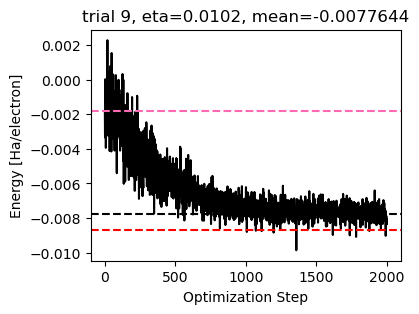

0.01033228626918582 -0.00786808189


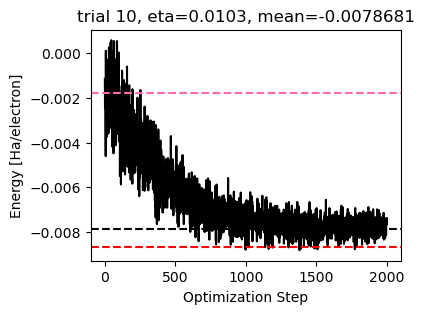

0.02243393061169456 -0.00773329773


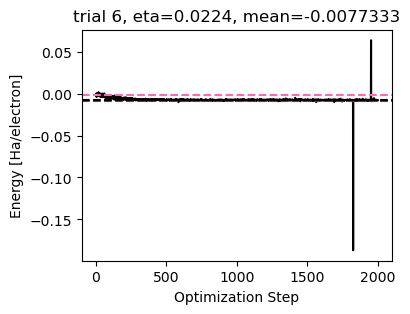

0.031917634735984635 -0.0077265026


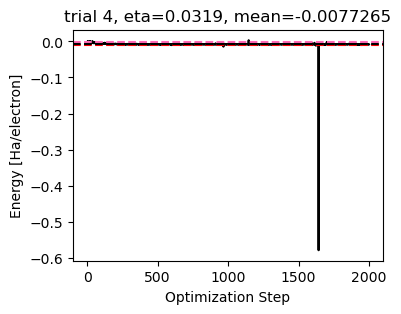

0.06772288595016049 -0.00519071707


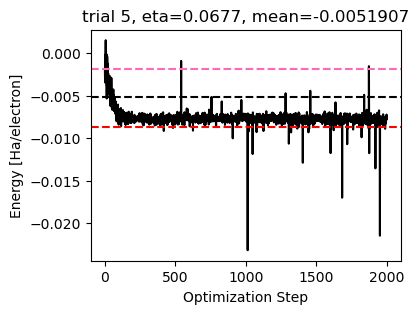

0.07829174372984872 -0.00816440854


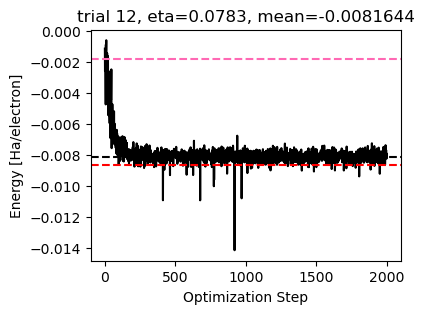

0.0912070748236938 -0.00761771943


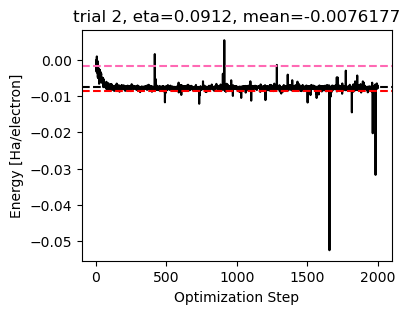

0.4948053818492574 -0.00772009644


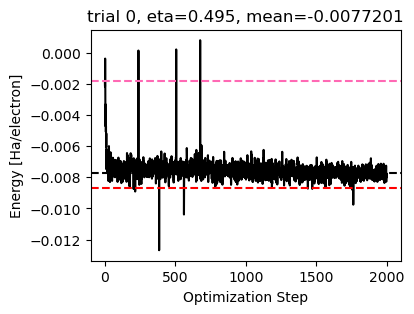

0.5258515804878422 -0.00820488512


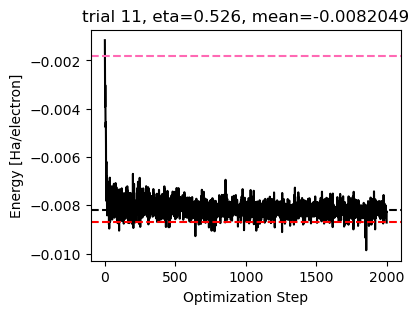

1.3684358769549434 -0.0134108189


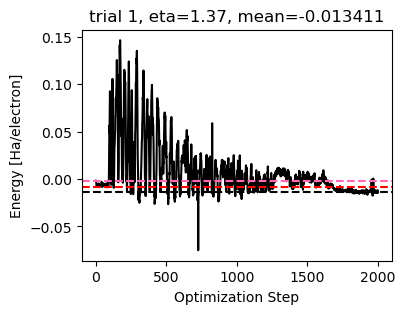

2.002678450862843 -0.199960807


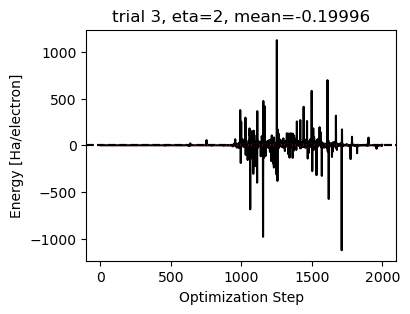

3.009044412796538 0.0996498917


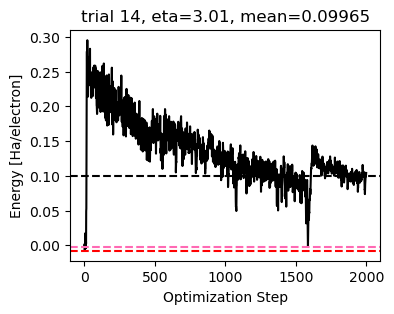

eta = 3.7858115263295278 failed
5.9720701385664725 0.181833613


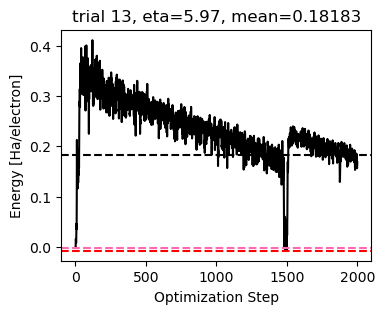

eta = 6.979376798279699 failed
eta = 7.884488370021597 failed


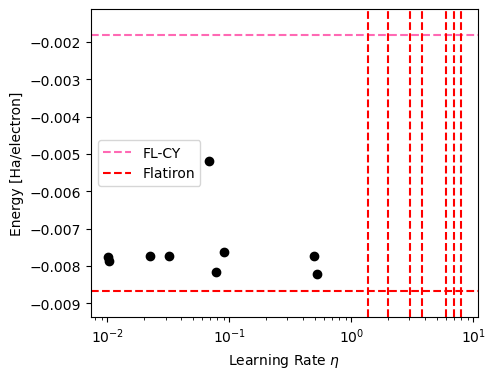

In [ ]:
path = "joint/{}/rs{}_best/{}"

r_ws = "30"
dim = 2

final_vals = []
etas = []

if dim == 2:
    hard_vals = {
        "10" : ( -0.084474 , np.nan , np.nan ),
        "20" : ( -0.045929 , -0.045975 , -0.04637 ),
        "30" : ( -0.031689 , -0.031807 , -0.03197 ),
        "40" : ( -0.0242460 , -0.0243690 , -0.024451 )
    }
elif dim == 3:
    hard_vals = {
        "1" : ( 0.5780, np.nan, 0.56861 ),
        "2" : ( -0.00181, np.nan, -0.00868 ),
        "5" : ( -0.0764, np.nan, -0.08002 ),
        "10" : ( -0.0534, np.nan, -0.0552126 ),
        "20" : ( -0.0316, np.nan, -0.0324553 ),
        "50" : ( -0.0143, np.nan, -0.01462631 ),
        "100" : ( -0.00760, np.nan, -0.00773018 ),
    }

for trial in range(16):
    
    eta = np.loadtxt(path.format(
        r_ws, str(trial), "hyperparameters.txt"
    ))

    etas.append(eta)

    try:
        (mean,_) = trajectory.getStatistics(path.format(
            r_ws, str(trial), "statistics.txt"
        ))
        energy_traj = np.loadtxt(path.format(
            r_ws, str(trial), "energy_traj.txt"
        ))
        final_vals.append((eta, mean, energy_traj))
    except:
        final_vals.append((eta, None, None))

if PLOT_INDIVIDUAL_TRAJ:

    eta_order = np.argsort(etas)

    for i in eta_order:
        
        eta = etas[i]
        _, mean, energy_traj = final_vals[i]

        if mean is None or energy_traj is None:
            print("eta = {} failed".format(eta))
            continue;
    
        print(eta, mean)

        ylim_range = hard_vals[r_ws][0] - hard_vals[r_ws][2]
        ylims = [ hard_vals[r_ws][2] - 0.1*ylim_range, hard_vals[r_ws][0] + 0.1*ylim_range ]

        plt.figure(figsize=(4,3))
        plt.plot(energy_traj, color='black')
        plt.axhline(y=hard_vals[r_ws][0], color='hotpink', linestyle='--', label='FL-CY')
        plt.axhline(y=hard_vals[r_ws][2], color='red', linestyle='--', label='Flatiron')
        plt.axhline(y=mean, color='black', linestyle='--', label='Result')
        #plt.ylim(ylims)
        plt.title("trial {}, eta={:.3g}, mean={:.5g}".format(i, eta, mean))
        plt.xlabel("Optimization Step")
        plt.ylabel("Energy [Ha/electron]")
        plt.show()

plt.figure(figsize=(5,4))

plt.axhline(y=hard_vals[r_ws][0], color='hotpink', linestyle='--', label='FL-CY')
plt.axhline(y=hard_vals[r_ws][2], color='red', linestyle='--', label='Flatiron')

ylim_range = hard_vals[r_ws][0] - hard_vals[r_ws][2]
ylims = [ hard_vals[r_ws][2] - 0.1*ylim_range, hard_vals[r_ws][0] + 0.1*ylim_range ]

for (eta, mean, energy_traj) in final_vals:
    if mean is None or mean > ylims[1] or mean < ylims[0]:
        plt.axvline(x=eta, color='red', linestyle='--')
    else:
        plt.scatter([eta], [mean], color='black')

plt.ylim(ylims)
plt.xscale('log')
plt.xlabel(r"Learning Rate $\eta$")
plt.ylabel("Energy [Ha/electron]")
plt.legend()
plt.show()

57.545092223895686 None
0.030487744466204017 0.570566566
0.20324240336532898 0.56917913
0.2905128326935245 0.56919333
5.404995709687086 1.86975316
0.6464883206334968 0.680998164
0.0156526353699295 0.569314402
1.2695990326610214 0.691559838
0.5172070265743356 0.639965982
0.6491168727395806 0.66388212
97.38623783150939 None
0.023379505882175463 0.569301281
3.0269291142355566 0.720274732
0.2761533133950843 0.569161413


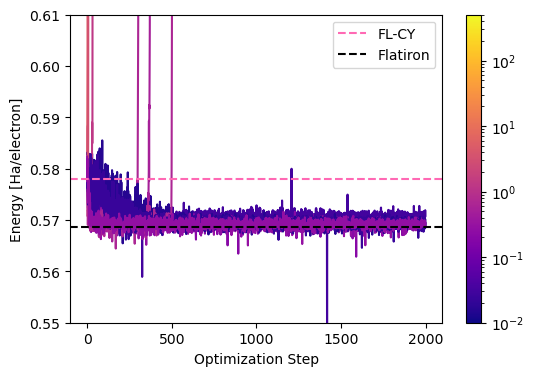

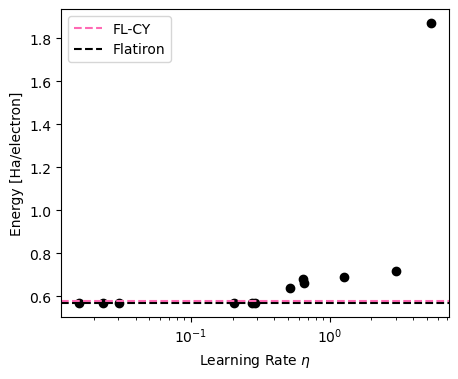

In [ ]:
path = "gaussian-reference/MP-init-gaussian/rs{}_trial{}/{}"
path = "salamander/NSJB-FL/rs{}_trial{}/{}"
path = "salamander/nomom/rs{}_trial{}/{}"
path = "rat/nomom/rs{}_trial{}/{}"

r_ws = "1"

cmap = plt.cm.plasma
norm = mpl.colors.LogNorm(1e-2, 5e2)

final_vals = []

plt.figure(figsize=(6,4))

# "r_ws" : ( FL_ref , WC_ref, flatiron )
hard_vals = {
    "1" : ( 0.5780, np.nan, 0.56861 ),
    "10" : ( -0.084474 , np.nan , np.nan ),
    "20" : ( -0.045929 , -0.045975 , -0.04637 ),
    "30" : ( -0.031689 , -0.031807 , -0.03197 ),
    "40" : ( -0.0242460 , -0.0243690 , -0.024451 ),
    "50" : ( -0.0196589 , -0.0197745 , -0.019829 )
}

for trial in range(16):
        
    eta = np.loadtxt(path.format(
        r_ws, str(trial), "hyperparameters.txt"
    ))

    try:
        energy_traj = np.loadtxt(path.format(
            r_ws, str(trial), "energy_traj.txt"
        ))

    except:
        final_vals.append([eta, None])
        continue;

    (mean,_) = trajectory.getStatistics(path.format(
        r_ws, str(trial), "statistics.txt"
    ))
    final_vals.append([eta, mean])

    print(eta, mean)

    if mean is None:
        continue;
    
    color = cmap(norm(eta))
    plt.plot(energy_traj, color=color)

plt.axhline(y=hard_vals[r_ws][0], color='hotpink', linestyle='--', label='FL-CY')
plt.axhline(y=hard_vals[r_ws][2], color='black', linestyle='--', label='Flatiron')

min_val = np.nanmin([hard_vals[r_ws][0],hard_vals[r_ws][2]])
max_val = np.nanmax([hard_vals[r_ws][0],hard_vals[r_ws][2]])
#plt.ylim([1.1*min_val,0.9*max_val])

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # older matplotlib compatibility
cbar = plt.colorbar(sm, ax=plt.gca())

if r_ws == "10":
    plt.ylim([-0.09, -0.08])
elif r_ws == "20":
    plt.ylim([-0.047, -0.045])
elif r_ws == "30":
    plt.ylim([-0.0325, -0.0315])
elif r_ws == "50":
    plt.ylim([-0.01984, -0.019625])
elif r_ws == "1":
    plt.ylim([0.55, 0.61])
else:
    raise Exception()

plt.xlabel("Optimization Step")
plt.ylabel("Energy [Ha/electron]")
plt.legend()
plt.show()

final_vals = np.array(final_vals)

plt.figure(figsize=(5,4))
plt.scatter(final_vals[:,0], final_vals[:,1], color='black')
plt.axhline(y=hard_vals[r_ws][0], color='hotpink', linestyle='--', label='FL-CY')
plt.axhline(y=hard_vals[r_ws][2], color='black', linestyle='--', label='Flatiron')
plt.xscale('log')
plt.xlabel(r"Learning Rate $\eta$")
plt.ylabel("Energy [Ha/electron]")
plt.legend()
plt.show()

### Compare best runs

CYJastrow	-0.0459288735
MP	-0.0459896451
gaussian	-0.045971532


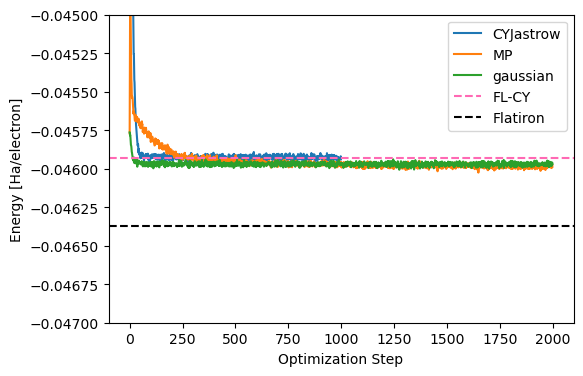

In [4]:
path = "{}/rs{}_best/{}"

r_ws = "20"
compare_vals = [
    ( "gaussian-reference/CYJastrow" , "CYJastrow" ),
    ( "gaussian-reference/MP-init-gaussian" , "MP" ),
    ( "gaussian-reference/gaussian" , "gaussian" ),
]

plt.figure(figsize=(6,4))

# "r_ws" : ( FL_ref , WC_ref, flatiron )
hard_vals = {
    "10" : ( -0.084474 , np.nan , np.nan ),
    "20" : ( -0.045929 , -0.045975 , -0.04637 ),
    "30" : ( -0.031689 , -0.031807 , -0.03197 ),
    "40" : ( -0.0242460 , -0.0243690 , -0.024451 ),
    "50" : ( -0.0196589 , -0.0197745 , -0.019829 )
}

for (filename, label) in compare_vals:

    energy_traj = np.loadtxt(path.format(
        filename, r_ws, "energy_traj.txt"
    ))

    (mean,_) = trajectory.getStatistics(path.format(
        filename, r_ws, "statistics.txt"
    ))

    print("{}\t{}".format(label, mean))

    if mean is None:
        continue;
    
    plt.plot(energy_traj, label=label)

plt.axhline(y=hard_vals[r_ws][0], color='hotpink', linestyle='--', label='FL-CY')
plt.axhline(y=hard_vals[r_ws][2], color='black', linestyle='--', label='Flatiron')

if r_ws == "10":
    plt.ylim([-0.09, -0.08])
elif r_ws == "20":
    plt.ylim([-0.047, -0.045])
elif r_ws == "30":
    plt.ylim([-0.0325, -0.0315])
else:
    raise Exception()

plt.xlabel("Optimization Step")
plt.ylabel("Energy [Ha/electron]")
plt.legend()
plt.show()